In [ ]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# ตั้งค่า path โดยใช้ PROJECT_ROOT จาก config_loader
sys.path.insert(0, os.path.abspath('..'))
from src.utils.config_loader import get_project_root, CONFIG
PROJECT_ROOT = get_project_root()

RAW_DIR = os.path.join(PROJECT_ROOT, CONFIG['data']['raw_dir'])
PROCESSED_DIR = os.path.join(PROJECT_ROOT, CONFIG['data']['processed_dir'])
IMAGES_DIR = os.path.join(PROJECT_ROOT, CONFIG['data']['images_dir'])
GRAPH_DIR = os.path.join(PROJECT_ROOT, CONFIG['data']['graph_dir'])

# (Optional) พิมพ์ตรวจสอบ
print(f"RAW_DIR: {RAW_DIR}")
print(f"PROCESSED_DIR: {PROCESSED_DIR}")
print(f"IMAGES_DIR: {IMAGES_DIR}")
print(f"GRAPH_DIR: {GRAPH_DIR}")


RAW_DIR: /Users/mati/hybrid_gat_cnn/data/raw
PROCESSED_DIR: /Users/mati/hybrid_gat_cnn/data/processed
IMAGES_DIR: /Users/mati/hybrid_gat_cnn/outputs/images
GRAPH_DIR: /Users/mati/hybrid_gat_cnn/outputs/graph_data


In [1]:
def load_raw_country(file_name, country_name):
    df = pd.read_csv(os.path.join(RAW_DIR, file_name))
    df.columns = df.columns.str.strip()
    rename_map = {}
    for col in df.columns:
        if col.lower() == 'tender':
            rename_map[col] = 'Tender'
        elif col.lower() == 'bid_value':
            rename_map[col] = 'Bid_value'
        elif col.lower() == 'competitors':
            rename_map[col] = 'Competitors'
        elif col.lower() == 'winner':
            rename_map[col] = 'Winner'
        elif col.lower() == 'collusive_competitor':
            rename_map[col] = 'Collusive_competitor'
        elif col.lower() == 'number_bids':
            rename_map[col] = 'Number_bids'
        elif col.lower() == 'date':
            rename_map[col] = 'Date'
        elif col.lower() == 'difference bid/pte':
            rename_map[col] = 'overprice_ratio'
    df = df.rename(columns=rename_map)
    df['Country'] = country_name
    return df

df_br_raw = load_raw_country("DB_Collusion_Brazil_processed.csv", "Brazil")
df_jp_raw = load_raw_country("DB_Collusion_Japan_processed.csv", "Japan")
df_us_raw = load_raw_country("DB_Collusion_America_processed.csv", "USA")

# Preprocess raw to create cleaned data (filter min_bids, normalize bid)
min_bids = CONFIG['preprocessing']['min_bids']  # 2

def preprocess_raw(df, country_name):
    df = df[df['Number_bids'] >= min_bids].copy()
    # Normalize Bid_value per tender
    min_vals = df.groupby('Tender')['Bid_value'].transform('min')
    max_vals = df.groupby('Tender')['Bid_value'].transform('max')
    range_vals = max_vals - min_vals
    df['Bid_norm'] = np.where(range_vals > 0, (df['Bid_value'] - min_vals) / range_vals, 0.5)
    if 'Collusive_competitor' in df.columns:
        df.rename(columns={'Collusive_competitor': 'label'}, inplace=True)
    df['Country'] = country_name
    return df

df_br_clean = preprocess_raw(df_br_raw, "Brazil")
df_jp_clean = preprocess_raw(df_jp_raw, "Japan")
df_us_clean = preprocess_raw(df_us_raw, "USA")

print("Cleaned columns Brazil:", df_br_clean.columns.tolist())

NameError: name 'pd' is not defined

In [3]:
raw_stats = []
for df, country in zip([df_br_raw, df_jp_raw, df_us_raw], ['Brazil','Japan','USA']):
    tender_col = 'Tender' if 'Tender' in df.columns else 'tender_id'
    total_bids = len(df)
    total_tenders = df[tender_col].nunique()
    avg_bids = total_bids / total_tenders
    raw_stats.append({
        'Country': country,
        'Raw Tenders': total_tenders,
        'Raw Bids': total_bids,
        'Avg Bidders/Tender': round(avg_bids, 2)
    })
raw_df = pd.DataFrame(raw_stats)
print("\n=== Raw Data Overview ===")
display(raw_df)


=== Raw Data Overview ===


,Country,Raw Tenders,Raw Bids,Avg Bidders/Tender
0,Brazil,101,683,6.76
1,Japan,1080,13515,12.51
2,USA,3754,7004,1.87


In [4]:
clean_stats = []
for df, country in zip([df_br_clean, df_jp_clean, df_us_clean], ['Brazil','Japan','USA']):
    total_bids = len(df)
    total_tenders = df['Tender'].nunique()
    avg_bids = total_bids / total_tenders
    tender_collusive = df.groupby('Tender')['label'].max()
    pct_collusive = (tender_collusive.sum() / len(tender_collusive)) * 100
    clean_stats.append({
        'Country': country,
        'Cleaned Tenders': total_tenders,
        'Cleaned Bids': total_bids,
        'Avg Bidders/Tender': round(avg_bids, 2),
        '% Collusive Tenders': round(pct_collusive, 1)
    })
clean_df = pd.DataFrame(clean_stats)
print("\n=== Statistics After min_bids=2 ===")
display(clean_df)


=== Statistics After min_bids=2 ===


,Country,Cleaned Tenders,Cleaned Bids,Avg Bidders/Tender,% Collusive Tenders
0,Brazil,101,683,6.76,32.7
1,Japan,1080,13515,12.51,11.4
2,USA,2233,5483,2.46,17.7


=== Debug: Check data label before create graph ===
Brazil: counts = {0: 540, 1: 143}
Japan: counts = {0: 11992, 1: 1523}
USA: counts = {0: 4330, 1: 1153}


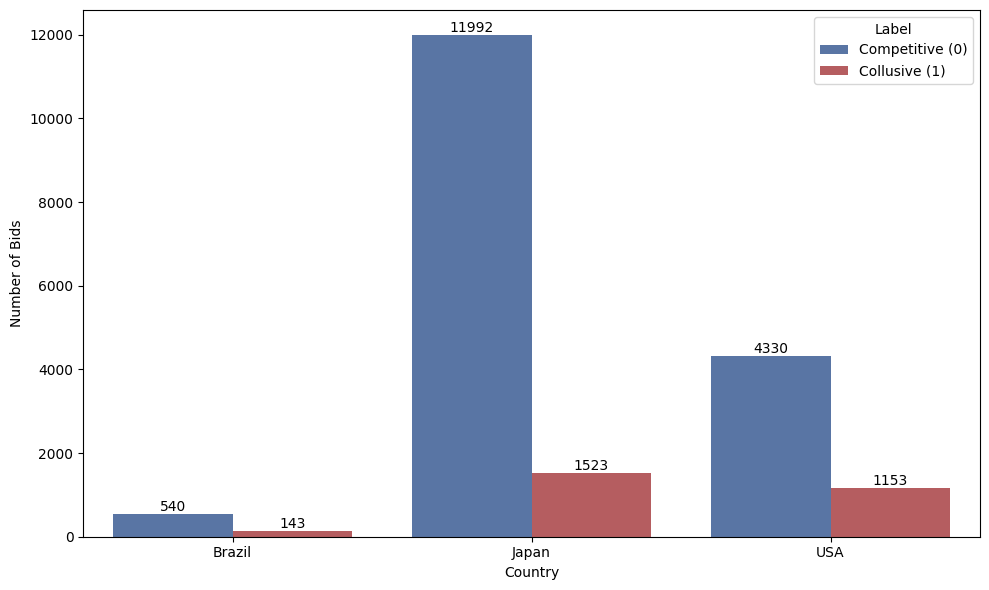

In [5]:
print("=== Debug: Check data label before create graph ===")
countries_data = [('Brazil', df_br_clean), ('Japan', df_jp_clean), ('USA', df_us_clean)]

plot_data = []
for country, df in countries_data:
    if df['label'].dtype == 'object':
        df['label'] = df['label'].astype(int)
    counts = df['label'].value_counts().to_dict()
    print(f"{country}: counts = {counts}")
    plot_data.append({'Country': country, 'label': 0, 'count': counts.get(0, 0)})
    plot_data.append({'Country': country, 'label': 1, 'count': counts.get(1, 0)})

plot_df = pd.DataFrame(plot_data)

plt.figure(figsize=(10,6))
ax = sns.barplot(data=plot_df, x='Country', y='count', hue='label', palette=['#4C72B0','#C44E52'])
plt.xlabel('Country')
plt.ylabel('Number of Bids')
handles, previous_labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, title='Label', labels=['Competitive (0)','Collusive (1)'])
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()


=== Statistical Summary of overprice_ratio (Difference Bid/PTE) ===
                 count   mean    std    min    25%    50%    75%    max
Country label                                                          
Brazil  0        540.0  0.155  0.302 -0.782 -0.042  0.109  0.280  1.958
        1        143.0  0.391  0.335 -0.169  0.181  0.310  0.505  1.683
Japan   0      11992.0  0.957  0.148  0.584  0.951  0.987  0.994  9.905
        1       1523.0  0.981  0.045  0.780  0.989  0.993  0.996  1.012

--- Key statistics for discussion (Median & IQR) ---
Brazil | Competitive: median = 0.109, IQR = [-0.042, 0.280]
Brazil | Collusive: median = 0.310, IQR = [0.181, 0.505]
Japan | Competitive: median = 0.987, IQR = [0.951, 0.994]
Japan | Collusive: median = 0.993, IQR = [0.989, 0.996]

--- Difference in medians (Collusive - Competitive) ---
Brazil: Δmedian = 0.201
Japan: Δmedian = 0.007


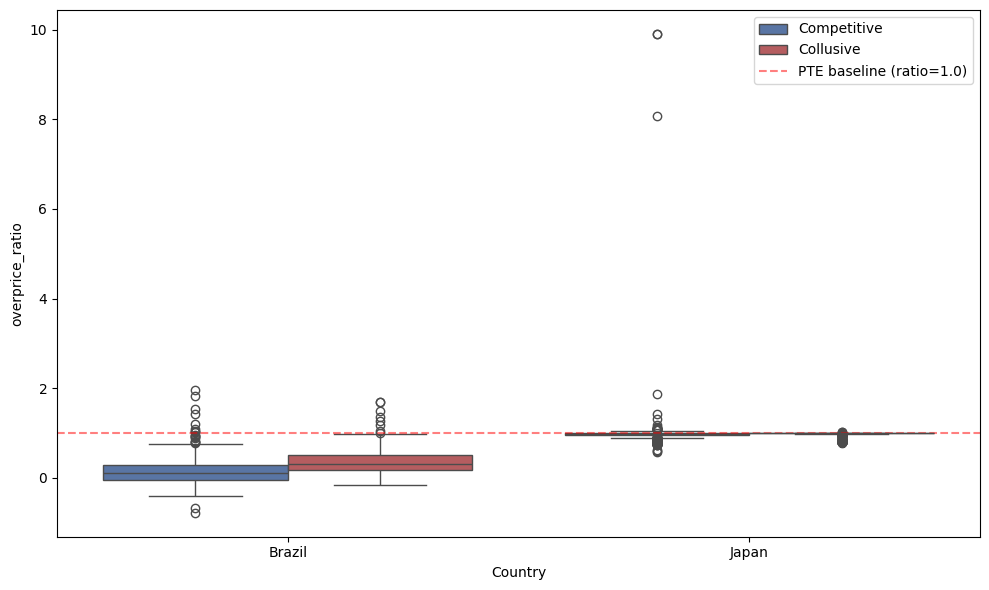

In [6]:
df_over = pd.concat([df_br_clean, df_jp_clean])[['Country','overprice_ratio','label']].dropna()
if not df_over.empty:
    print("\n=== Statistical Summary of overprice_ratio (Difference Bid/PTE) ===")
    stats_over = df_over.groupby(['Country', 'label'])['overprice_ratio'].describe(percentiles=[.25, .5, .75])
    print(stats_over.round(3))
    
    print("\n--- Key statistics for discussion (Median & IQR) ---")
    for country in ['Brazil', 'Japan']:
        for lbl, name in [(0, 'Competitive'), (1, 'Collusive')]:
            subset = df_over[(df_over['Country']==country) & (df_over['label']==lbl)]
            if not subset.empty:
                med = subset['overprice_ratio'].median()
                q1 = subset['overprice_ratio'].quantile(0.25)
                q3 = subset['overprice_ratio'].quantile(0.75)
                print(f"{country} | {name}: median = {med:.3f}, IQR = [{q1:.3f}, {q3:.3f}]")
    
    print("\n--- Difference in medians (Collusive - Competitive) ---")
    for country in ['Brazil', 'Japan']:
        comp_med = df_over[(df_over['Country']==country) & (df_over['label']==0)]['overprice_ratio'].median()
        coll_med = df_over[(df_over['Country']==country) & (df_over['label']==1)]['overprice_ratio'].median()
        if not np.isnan(comp_med) and not np.isnan(coll_med):
            diff = coll_med - comp_med
            print(f"{country}: Δmedian = {diff:.3f}")
    
    df_over['label_name'] = df_over['label'].map({0:'Competitive',1:'Collusive'})
    plt.figure(figsize=(10,6))
    sns.boxplot(data=df_over, x='Country', y='overprice_ratio', hue='label_name', palette=['#4C72B0','#C44E52'])
    plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='PTE baseline (ratio=1.0)')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Note: 'overprice_ratio' not found, skip overpricing plot.")

In [7]:
print("\n" + "="*60)

# 1. Number of bids have label=1 (collusive) by country
print("\n1. Number of bids have label=1 (collusive) by country:")
for df, country in zip([df_br_clean, df_jp_clean, df_us_clean], ['Brazil','Japan','USA']):
    n_coll_bids = (df['label'] == 1).sum()
    print(f"   {country}: {n_coll_bids} จาก {len(df)} bids ({n_coll_bids/len(df)*100:.2f}%)")

# 2. Statistic overprice_ratio  Brazil and Japan
print("\n2. Statistic overprice_ratio (Difference Bid/PTE) by country and group:")
for country, df in zip(['Brazil','Japan'], [df_br_clean, df_jp_clean]):
    if 'overprice_ratio' in df.columns:
        stats = df.groupby('label')['overprice_ratio'].describe(percentiles=[.25, .5, .75])
        print(f"\n   {country}:")
        print(stats.round(3))
    else:
        print(f"\n   {country}: No overprice_ratio")

# 3. median and IQR 
print("\n3.  median and IQR of overprice_ratio:")
for country, df in zip(['Brazil','Japan'], [df_br_clean, df_jp_clean]):
    if 'overprice_ratio' in df.columns:
        for label, name in [(0,'Competitive'), (1,'Collusive')]:
            data = df[df['label']==label]['overprice_ratio'].dropna()
            if not data.empty:
                med = data.median()
                q1 = data.quantile(0.25)
                q3 = data.quantile(0.75)
                print(f"   {country} | {name}: median={med:.3f}, IQR=[{q1:.3f}, {q3:.3f}]")
            else:
                print(f"   {country} | {name}: No data")

# 4. % tenders USA that have n<4
tender_sizes = df_us_clean.groupby('Tender').size()
pct_lt4 = (tender_sizes < 4).mean() * 100
print(f"\n4. Portion USA bidder less than 4 : {pct_lt4:.1f}%")
print("   (Reson Excess Kurtosis - KURT)")



1. Number of bids have label=1 (collusive) by country:
   Brazil: 143 จาก 683 bids (20.94%)
   Japan: 1523 จาก 13515 bids (11.27%)
   USA: 1153 จาก 5483 bids (21.03%)

2. Statistic overprice_ratio (Difference Bid/PTE) by country and group:

   Brazil:
       count   mean    std    min    25%    50%    75%    max
label                                                        
0      540.0  0.155  0.302 -0.782 -0.042  0.109  0.280  1.958
1      143.0  0.391  0.335 -0.169  0.181  0.310  0.505  1.683

   Japan:
         count   mean    std    min    25%    50%    75%    max
label                                                          
0      11992.0  0.957  0.148  0.584  0.951  0.987  0.994  9.905
1       1523.0  0.981  0.045  0.780  0.989  0.993  0.996  1.012

3.  median and IQR of overprice_ratio:
   Brazil | Competitive: median=0.109, IQR=[-0.042, 0.280]
   Brazil | Collusive: median=0.310, IQR=[0.181, 0.505]
   Japan | Competitive: median=0.987, IQR=[0.951, 0.994]
   Japan | Collusiv

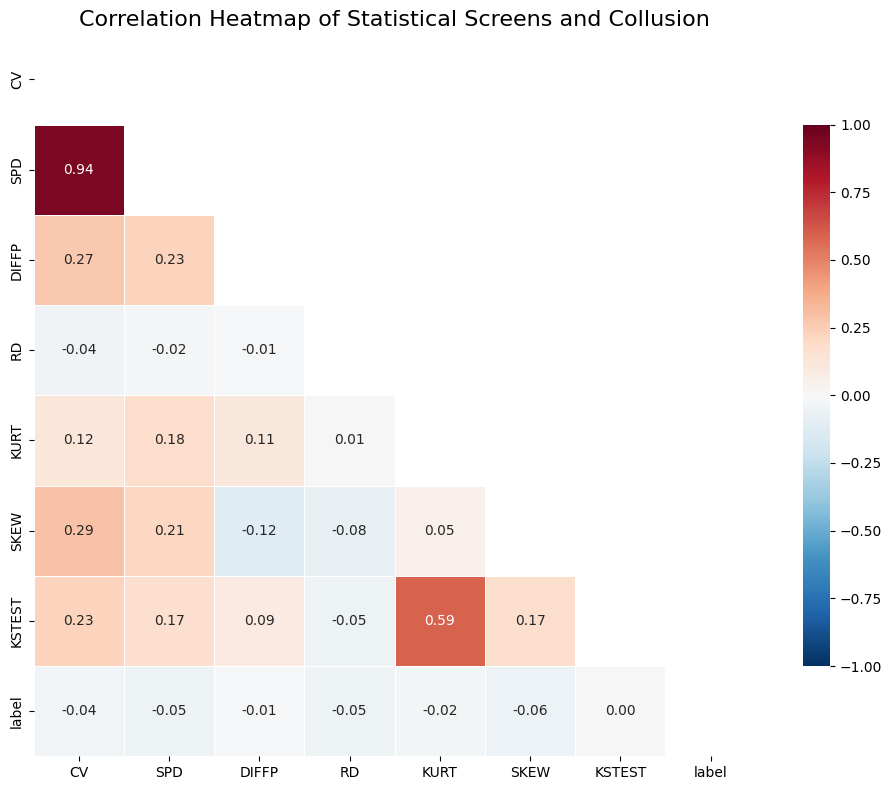

In [8]:
# All cleaned data 3 countries
df_all_clean = pd.concat([df_br_clean, df_jp_clean, df_us_clean], ignore_index=True)

screens = ['CV', 'SPD', 'DIFFP', 'RD', 'KURT', 'SKEW', 'KSTEST']
df_screens = df_all_clean[screens + ['label']].copy()
df_screens = df_screens.dropna()

corr = df_screens.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', fmt=".2f", vmin=-1, vmax=1,
            square=True, linewidths=.5, cbar_kws={"shrink": .75})
plt.title('Correlation Heatmap of Statistical Screens and Collusion', fontsize=16)
plt.tight_layout()
plt.show()

### After create graph and images run this for check

#### Stage 1: Pair-level Images (min_interactions=3)

In [ ]:
pair_stats = []
for c in ['brazil','japan','usa']:
    lbl_path = os.path.join(IMAGES_DIR, f"{c}_pair_labels.csv")
    if os.path.exists(lbl_path):
        lbl = pd.read_csv(lbl_path)
        n_pairs = len(lbl)
        n_coll = (lbl['label']==1).sum()
        pct_coll = 100*n_coll/n_pairs
        pair_stats.append({'Country':c.capitalize(), 'Total Pairs':n_pairs, 'Collusive Pairs':n_coll, '% Collusive':round(pct_coll,1)})
pair_df = pd.DataFrame(pair_stats)
print("\n=== Stage 1: Pair-level Images (min_interactions=3) ===")
display(pair_df)



=== Stage 1: Pair-level Images (min_interactions=3) ===


,Country,Total Pairs,Collusive Pairs,% Collusive
0,Brazil,66,37,56.1
1,Japan,5556,1992,35.9
2,Usa,185,69,37.3


#### Stage 2: Tender-level Graph

In [15]:

graph_stats = []
for c in ['brazil','japan','usa']:
    gpath = os.path.join(GRAPH_DIR, f"{c}_graph.pt")
    if os.path.exists(gpath):
        data = torch.load(gpath, map_location='cpu', weights_only=False)
        n_nodes = data.x.size(0)
        n_edges = data.edge_index.size(1)//2
        graph_stats.append({'Country':c.capitalize(), 'Nodes (tenders)':n_nodes, 'Edges (undirected)':n_edges})
graph_df = pd.DataFrame(graph_stats)
print("\n=== Stage 2: Tender-level Graph ===")
display(graph_df)


=== Stage 2: Tender-level Graph ===


""
